# Random Forest Calcofi

Queremos determinar cuánta presencia hay y de qué tipo de peces en algunos puntos de la costa Californiana. Particularmente de nuestras variables objetivo:

• Engraulis mordax (Anchoa)

• Sardinops sagax (Sardina)

In [1]:
import pandas as pd

bottle = pd.read_csv("../../data/raw/bottle.csv")
cast = pd.read_csv("../../data/raw/cast.csv")
biologico = pd.read_csv("../../data/raw/biologico/calcofi_ichthyo/occurrence.txt",sep="\t")

# vamos a necesitar el tamaño de los dataset que tenemos

biologico.shape


/tmp/ipykernel_19581/2920896956.py:3: DtypeWarning: Columns (0: IncTim, 1: DIC Quality Comment) have mixed types. Specify dtype option on import or set low_memory=False.
  bottle = pd.read_csv("../../data/raw/bottle.csv")
/tmp/ipykernel_19581/2920896956.py:4: DtypeWarning: Columns (0: Data_Or, 1: Cruz_Num, 2: Inc_Str, 3: Inc_End, 4: PST_LAN, 5: Civil_T) have mixed types. Specify dtype option on import or set low_memory=False.
  cast = pd.read_csv("../../data/raw/cast.csv")


(463655, 13)

Biologico: 463655 Filas con especies de peces, larvas, huevos etc y 13 columnas de observaciones 

In [2]:
cast.shape

(34404, 61)

Cast: 34404 Filas con datos de hora, fecha y lugares de "lanzadas" al mar y 61 columnas de sus condiciones

In [3]:
bottle.shape

(864863, 74)

Bottle: 864863 Filas con sus botellas definidas y 74 columnas de informacion que recolectaron éstas

## 1. Preparación y limpieza de los Datos (Data Preprocessing) 
De éstos 3 dataset, elegimos las variables más relevantes y la unimos en dataset_final


In [4]:
import numpy as np

### Variables Finales del Dataset Unificado (`dataset_final`)

| N° | Columna | Categoría | Descripción / Unidades |
| :---: | :--- | :--- | :--- |
| 1 | `occurrenceID` | Identificador | ID único de la ocurrencia biológica |
| 2 | `scientificName` | Biológica | Nombre científico de la especie (*Sardinops sagax* / *Engraulis mordax*) |
| 3 | `Year` | Temporal | Año del muestreo |
| 4 | `Month` | Temporal | Mes del muestreo |
| 5 | `Lat_Dec` | Espacial | Latitud en grados decimales |
| 6 | `Lon_Dec` | Espacial | Longitud en grados decimales |
| 7 | `Sta_ID` | Estación | Identificador de la estación oceanográfica |
| 8 | `Cruise_ID` | Crucero | Identificador del crucero de investigación |
| 9 | `T_degC` | Físico-Química | Temperatura del agua (°C) |
| 10 | `Salnty` | Físico-Química | Salinidad del agua (PSU) |
| 11 | `STheta` | Físico-Química | Densidad potencial ($\sigma_\theta$) |
| 12 | `O2ml_L` | Físico-Química | Oxígeno disuelto (mL/L) |
| 13 | `O2Sat` | Físico-Química | Saturación de oxígeno (%) |
| 14 | `Oxy_µmol/Kg` | Físico-Química | Oxígeno disuelto ($\mu\text{mol/kg}$) |
| 15 | `ChlorA` | Nutrientes/Pigmentos | Clorofila-a ($\mu\text{g/L}$) |
| 16 | `Phaeop` | Nutrientes/Pigmentos | Feopigmentos ($\mu\text{g/L}$) |
| 17 | `PO4uM` | Nutrientes/Pigmentos | Fosfatos ($\mu\text{mol/L}$) |
| 18 | `SiO3uM` | Nutrientes/Pigmentos | Silicatos ($\mu\text{mol/L}$) |
| 19 | `NO2uM` | Nutrientes/Pigmentos | Nitritos ($\mu\text{mol/L}$) |
| 20 | `NO3uM` | Nutrientes/Pigmentos | Nitratos ($\mu\text{mol/L}$) |
| 21 | `Distance` | Geográfica | Distancia a la costa |
| 22 | `Bottom_D` | Geográfica | Profundidad total del fondo marino ($m$) |
| 23 | `IntChl` | Geográfica | Clorofila integrada en la columna de agua ($mg/m^2$) |
| 24 | `Wind_Spd` | Meteorológica | Velocidad del viento (nudos) |
| 25 | `Wave_Ht` | Meteorológica | Altura de la ola ($m$) |
| 26 | `Barometer` | Meteorológica | Presión barométrica (hPa / mbar) |
| 27 | `Dry_T` | Meteorológica | Temperatura del aire seco (°C) |
| 28 | `Wet_T` | Meteorológica | Temperatura de bulbo húmedo (°C) |


In [5]:
variables_finales = [ "Depthm", "T_degC", "Salnty", "O2ml_L", "STheta", "O2Sat", "Oxy_µmol/Kg", "ChlorA", "Phaeop", "PO4uM", "SiO3uM", "NO2uM", "NO3uM", "NH3uM", "pH1", "pH2", "TA1", "TA2", "DIC1", "DIC2" ]


Nuestra variables objetivos Y: se encuentra en scientificName, Nombre científico de la especie
(*Sardinops sagax* / *Engraulis mordax*)

## Tratamiento de valores nulos 
Es mejor imputarlos (con la mediana o moda). Nosotros vamos a utilizar la mediana así nuestras variables numéricas no se ven afectada por los valores extremos (outliers)

Antes que nada debemos unir algunas variables de Fecha y hora en cada tabla para poder filtrar datos y aplicarles la mediana

In [6]:
# Este paso lo tuve que hacer de nuevo y antes de tratar los valores Nulos porque el EDA es parte de otro documento


# Inspeccionar qué columnas de tiempo/fecha existen en cada tabla
print("--- Columnas en bottle ---")
print([c for c in bottle.columns if any(p in c.lower() for p in ['year', 'date', 'month', 'time'])])

print("\n--- Columnas en cast ---")
print([c for c in cast.columns if any(p in c.lower() for p in ['year', 'date', 'month', 'time'])])

print("\n--- Columnas en biologico ---")
print([c for c in biologico.columns if any(p in c.lower() for p in ['year', 'date', 'month', 'time'])])

--- Columnas en bottle ---
[]

--- Columnas en cast ---
['Date', 'Year', 'Month', 'Julian_Date', 'Time', 'TimeZone']

--- Columnas en biologico ---
[]


Existen algunas en Cast, unimos Bottle y Cast por la variable Cst_Cnt (Recuento de lances: todos los lances de CalCOFI realizados hasta la fecha, numerados consecutivamente)

In [7]:
import pandas as pd

# 1. Unir bottle y cast usando la clave primaria 'Cst_Cnt'
df_ocean = pd.merge(bottle, cast, on='Cst_Cnt', how='inner', suffixes=('', '_cast'))
print(f'df_ocean es bottle + Cast unidos por Cst_Cnt  (muestreos) Filas: {len(df_ocean):,}')

# 2. Ver todas las columnas de 'biologico' para identificar fecha, año y coordenadas
print('\n--- TODAS LAS COLUMNAS DE BIOLOGICO ---')
print(biologico.columns.tolist())

df_ocean es bottle + Cast unidos por Cst_Cnt  (muestreos) Filas: 864,863

--- TODAS LAS COLUMNAS DE BIOLOGICO ---
['id', 'modified', 'basisOfRecord', 'occurrenceID', 'organismQuantity', 'organismQuantityType', 'lifeStage', 'occurrenceStatus', 'preparations', 'eventID', 'scientificNameID', 'scientificName', 'kingdom']


In [8]:
# Uniendo Event que tiene datos de fecha y lugar y biologico que tiene de peces

import pandas as pd

# 1. Cargar el archivo event.txt (contiene fechas, coordenadas y estaciones)
ruta_biolib = "../../data/raw/biologico/calcofi_ichthyo/"
event = pd.read_csv(ruta_biolib + 'event.txt', sep='\t', low_memory=False)

In [9]:
# 2. Unir occurrence con event usando eventID (Identificador del muestreo)
biologico_completo = pd.merge(biologico, event, on='eventID', how='inner')

print(f'Datos biológicos y Event unidos, Filas: {len(biologico_completo):,}')

# 3. Mostrar las nuevas columnas para ver cómo cruzarlas con df_ocean
print('\n--- COLUMNAS DISPONIBLES EN EL BIOLÓGICO COMPLETO ---')
print(biologico_completo.columns.tolist())

Datos biológicos y Event unidos, Filas: 463,655

--- COLUMNAS DISPONIBLES EN EL BIOLÓGICO COMPLETO ---
['id_x', 'modified', 'basisOfRecord', 'occurrenceID', 'organismQuantity', 'organismQuantityType', 'lifeStage', 'occurrenceStatus', 'preparations', 'eventID', 'scientificNameID', 'scientificName', 'kingdom', 'id_y', 'datasetID', 'parentEventID', 'eventType', 'eventDate', 'habitat', 'samplingProtocol', 'sampleSizeValue', 'sampleSizeUnit', 'eventRemarks', 'locationID', 'decimalLatitude', 'decimalLongitude', 'geodeticDatum', 'coordinateUncertaintyInMeters', 'footprintWKT']


Tenemos 463,655 filas biológicas unidas con sus eventos espaciales y temporales correspondientes.

In [10]:
import pandas as pd

# 1. Asegurar que tengamos año y mes listos en biologico_completo a partir de eventDate (Fecha del muestreo biológico)

biologico_completo['eventDate'] = pd.to_datetime(biologico_completo['eventDate'], errors='coerce')
biologico_completo['Year'] = biologico_completo['eventDate'].dt.year
biologico_completo['Month'] = biologico_completo['eventDate'].dt.month


In [11]:

# 2. Redondear coordenadas para facilitar el cruce espacial exacto con las estaciones CalCOFI

biologico_completo['lat_round'] = biologico_completo['decimalLatitude'].round(2)
biologico_completo['lon_round'] = biologico_completo['decimalLongitude'].round(2)
df_ocean['lat_round'] = df_ocean['Lat_Dec'].round(2)
df_ocean['lon_round'] = df_ocean['Lon_Dec'].round(2)

/tmp/ipykernel_19581/1824426403.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ocean['lat_round'] = df_ocean['Lat_Dec'].round(2)
/tmp/ipykernel_19581/1824426403.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ocean['lon_round'] = df_ocean['Lon_Dec'].round(2)


In [12]:

# 1. Filtrar SOLO las dos especies que te interesan antes de fusionar para que no se nos rompa el Kernel, al fin y al cabo solo buscamos 2

especies_objetivo = ['Sardinops sagax', 'Engraulis mordax']
biologico_filtrado = biologico_completo[biologico_completo['scientificName'].isin(especies_objetivo)].copy()

print(f' Registros biológicos para sardina/anchoa: {len(biologico_filtrado):,}')

# 2. Preparar campos de fecha y coordenadas redondeadas en el biológico
biologico_filtrado['eventDate'] = pd.to_datetime(
    biologico_filtrado['eventDate'], errors='coerce'
)
biologico_filtrado['Year'] = biologico_filtrado['eventDate'].dt.year
biologico_filtrado['Month'] = biologico_filtrado['eventDate'].dt.month
biologico_filtrado['lat_round'] = biologico_filtrado['decimalLatitude'].round(2)
biologico_filtrado['lon_round'] = biologico_filtrado['decimalLongitude'].round(2)


 Registros biológicos para sardina/anchoa: 55,370


In [13]:
# Asegurar coordenadas redondeadas en df_ocean (recordemos: df_ocean = bottle y cast unidas por Cst_Cnt (Recuento de lances)
df_ocean['lat_round'] = df_ocean['Lat_Dec'].round(2)
df_ocean['lon_round'] = df_ocean['Lon_Dec'].round(2)

In [14]:
# 3. Hacer el merge final con el subset reducido
dataset_final = pd.merge(df_ocean, biologico_filtrado, on=['Year', 'Month', 'lat_round', 'lon_round'],how='inner',)

print( f'Dimensiones de dataset_final : {dataset_final.shape}')

Dimensiones de dataset_final : (465560, 165)


#### dataset_final es Bottle, Cast, Biologico y Event unidos por fecha , muestreo, lat y long o sea el cuándo, el cómo y dónde. 
#### También están los registros de Anchoas y Sardinas

•  Tiene 465560 Filas con 165 columnas con todos sus valores enteros, sin limpiar


# Tratamiento de valores nulos
Ahora veremos que hacer con aquellos valores que son NaN o no dicen nada. Les aplicaremos la mediana para no eliminarlos completamente

In [15]:

from sklearn.impute import SimpleImputer

# 1. Definir las principales variables numéricas / oceanográficas para tu modelo
features_num = ['T_degC', 'Salnty', 'Depthm', 'O2ml_L', 'ChlorA', 'STheta','PO4uM','NO3uM']

# Filtrar solo las columnas que realmente están presentes en tu dataset_final
cols_a_imputar = [c for c in features_num if c in dataset_final.columns]

# 2. Configurar el SimpleImputer utilizando la estrategia 'median'
imputador_mediana = SimpleImputer(strategy='median')

# 3. Aplicar la imputación directamente sobre esas columnas en dataset_final
dataset_final[cols_a_imputar] = imputador_mediana.fit_transform(
    dataset_final[cols_a_imputar]
)

# 4. Comprobar el resultado (debe dar 0 para todas las columnas seleccionadas)
print(' Valores nulos después de imputar con la mediana:')
print(dataset_final[cols_a_imputar].isna().sum())

 Valores nulos después de imputar con la mediana:
T_degC    0
Salnty    0
Depthm    0
O2ml_L    0
ChlorA    0
STheta    0
PO4uM     0
NO3uM     0
dtype: int64


# Conclusión
•  Esto significa que en dataset_final ya no queda ningún valor nulo (NaN) en ellas. Todos los espacios vacíos que había en el dataset fueron rellenados con éxito por la mediana correspondiente de cada variable

# Entrenando el modelo
## División train/test 
Sardina

In [16]:
# 1. Separar los datos específicamente para la variable objetivo Y: Sardina
df_sardina = dataset_final[
    dataset_final['scientificName'] == 'Sardinops sagax'].copy()

In [17]:

# 2. Definir Features (X) y Target (y) para la sardina

features_num = ['T_degC','Salnty','Depthm','O2ml_L','ChlorA','STheta','PO4uM','NO3uM',]

In [18]:
X = df_sardina[features_num]

In [19]:
y = df_sardina['organismQuantity']

In [20]:
print(f'Registros para entrenar modelo de Sardina: {len(df_sardina):,}')

Registros para entrenar modelo de Sardina: 113,656


Anchoa

In [21]:
# 1. Separar los datos específicamente para la variable objetivo Y: Anchoa

df_anchoa = dataset_final[dataset_final['scientificName'] == 'Engraulis mordax'].copy()

In [22]:
# 2. Definir Features (X) y Target (y) para la anchoa
features_num = ['T_degC','Salnty','Depthm','O2ml_L','ChlorA','STheta','PO4uM','NO3uM',]
X_anchoa = df_anchoa[features_num]
y_anchoa = df_anchoa['organismQuantity']

# convierte los datos de X_anchoa a 32 bits para reducir a la mitad el uso de memoria RAM
X_anchoa = X_anchoa.astype('float32')

print(f'Registros para entrenar modelo de Anchoa: {len(df_anchoa):,}')

Registros para entrenar modelo de Anchoa: 351,904


Dividiendo los datos en conjuntos de entrenamiento y prueba (80% y 20%)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import gc

Sardina

In [24]:
# 1. Definir Features y Target para la sardina
X_sardina = df_sardina[features_num].astype('float32')
y_sardina = df_sardina['organismQuantity'].astype('float32')

# 2. DIVISIÓN TRAIN/TEST (80% entrenamiento, 20% prueba)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split (X_sardina, y_sardina, test_size=0.2, random_state=42)

gc.collect()

print(f"Tamaño X_train_s: {X_train_s.shape}")
print(f"Tamaño X_test_s: {X_test_s.shape}")

Tamaño X_train_s: (90924, 8)
Tamaño X_test_s: (22732, 8)


In [25]:
# 3. Entrenar el modelo Random Forest
# print("Entrenando modelo de Sardina...")
# rf_sardina = RandomForestRegressor(
#    n_estimators=50, 
#   max_depth=15, 
#   n_jobs=-1, 
#   random_state=42)
# rf_sardina.fit(X_train_s, y_train_s)

In [26]:
# 4. Evaluar el rendimiento
# y_pred_s = rf_sardina.predict(X_test_s)
# r2_s = r2_score(y_test_s, y_pred_s)
# rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))

# print("\n Resultados Sardina:")
# print(f"  - R²: {r2_s:.4f}")
# print(f"  - RMSE: {rmse_s:.4f}")


# Resultados Sardina: 
# - R²: -0.1311 
# - RMSE: 596.6318

Primer resultado: malisima la prediccion.. Voy a imputar datos, eliminarlos en vez de utilizar la mediana

In [27]:
# Eliminar filas donde organismQuantity sea nulo
# df_sardina = df_sardina.dropna(subset=['organismQuantity'])

In [28]:
# Rellenar nulos de las features con la mediana de cada columna
# X_sardina = df_sardina[features_num].fillna(df_sardina[features_num].median())

In [29]:
# import pandas as pd
# import numpy as np
# import gc
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_squared_error, r2_score

In [30]:
# 1. Filtrar los datos originales para la sardina
# df_sardina = dataset_final[dataset_final['scientificName'] == 'Sardinops sagax'].copy()

# 2. ELIMINAR nulos de la variable objetivo (NUNCA se imputa el target)
# df_sardina = df_sardina.dropna(subset=['organismQuantity'])

# 3. Definir features y target
# features_num = ['T_degC', 'Salnty', 'Depthm', 'O2ml_L', 'ChlorA', 'STheta', 'PO4uM', 'NO3uM']

In [31]:
# 4. Imputar las features con la mediana (aquí sí es correcto porque son variables ambientales)
# X_sardina = df_sardina[features_num].fillna(df_sardina[features_num].median()).astype('float32')
# y_sardina = df_sardina['organismQuantity'].astype('float32')

# print(f'Registros limpios para Sardina: {len(df_sardina):,}')

# Registros limpios para Sardina: 113,656


In [32]:
# 5. División Train / Test
# X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
#   X_sardina, y_sardina, test_size=0.2, random_state=42)

# gc.collect()

In [33]:
# 6. Entrenar el Random Forest
# print("Entrenando modelo de Sardina corregido...")
# rf_sardina = RandomForestRegressor(
#    n_estimators=50, 
#   max_depth=15, 
#    n_jobs=-1, 
#    random_state=42)
# rf_sardina.fit(X_train_s, y_train_s)

In [34]:
# 7. Evaluar resultados
# y_pred_s = rf_sardina.predict(X_test_s)
# r2_s = r2_score(y_test_s, y_pred_s)
# rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))

# print("\n Nuevos Resultados Sardina:")
# print(f"  - R²: {r2_s:.4f}")
# print(f"  - RMSE: {rmse_s:.4f}")

# Nuevos Resultados Sardina:
# - R²: -0.1311
# - RMSE: 596.6318

Malisimo nos sigue dando un numero negativo

Vamos a hacer una prueba rápida para ver cómo están distribuidos los datos y refrescar todo. Veamos cuántos ceros hay

In [35]:
# print("Total de registros:", len(y_sardina))
# print("Cuántos son 0:", (y_sardina == 0).sum())
# print("Valor máximo:", y_sardina.max())
# print("Valor promedio:", y_sardina.mean())


# Total de registros: 113656
# Cuántos son 0: 0
# Valor máximo: 21344.0
# Valor promedio: 79.95325

Hay valores atípicos (outliers) gigantescos.
 El promedio de sardinas es de unas 80, pero hay muestras donde se registraron más de 21,000 organismos. Cuando un modelo de regresión intenta minimizar el error cuadrático (MSE) con datos tan extremadamente sesgados, los pocos valores gigantescos destruyen el modelo. El algoritmo intenta adaptarse a ellos, se equivoca horriblemente en el 99% de los datos restantes, y por eso el $R^2$ da negativo (-0.1311).

Aplicar una transformación logarítmica
En ecología, cuando la abundancia de especies tiene este comportamiento (muchos valores pequeños/moderados y unos pocos valores extremos altísimos), la solución estándar es aplicar un logaritmo (np.log1p) a la variable objetivo (organismQuantity). Esto "aplana" la curva, reduce el impacto de los valores locos y permite que el Random Forest aprenda de verdad.

In [36]:
# 1. Definir features y target limpio
# features_num = ['T_degC', 'Salnty', 'Depthm', 'O2ml_L', 'ChlorA', 'STheta', 'PO4uM', 'NO3uM']
# cols_a_revisar = features_num + ['organismQuantity']
# df_sardina_clean = df_sardina.dropna(subset=cols_a_revisar).copy()

# X_sardina = df_sardina_clean[features_num].astype('float32')

In [37]:
# 2. APLICAR LOGARITMO A Y PARA CONTROLAR LOS OUTLIERS DE 21,000
# y_sardina_log = np.log1p(df_sardina_clean['organismQuantity']).astype('float32')

# 3. Split
# X_train_s, X_test_s, y_train_s_log, y_test_s_log = train_test_split(
#    X_sardina, y_s_log := y_sardina_log, test_size=0.2, random_state=42)

# gc.collect()

# Resultado: 96

In [38]:
# 4. Entrenar
# print("Entrenando modelo con transformación logarítmica...")
# rf_sardina = RandomForestRegressor(
#    n_estimators=50, 
#    max_depth=15, 
#    n_jobs=-1, 
#   random_state=42)
# rf_sardina.fit(X_train_s, y_train_s_log)

In [39]:
# 5. Predecir y revertir el logaritmo (expm1) para evaluar en la escala real
# y_pred_log = rf_sardina.predict(X_test_s)
# y_pred_real = np.expm1(y_pred_log)
# y_test_real = np.expm1(y_test_s_log)

In [40]:
# 6. Métricas finales en escala real
# r2_s = r2_score(y_test_real, y_pred_real)
# rmse_s = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

# print("\n Resultados con Transformación Logarítmica:")
# print(f"  - R²: {r2_s:.4f}")
# print(f"  - RMSE: {rmse_s:.4f}")



# Resultados con Transformación Logarítmica:
#  - R²: -0.0124
#  - RMSE: 564.4638

1. ¿Estamos evaluando el $R^2$ en la escala correcta?Cuando aplicas logaritmos (np.log1p), el modelo aprende en "escala logarítmica". Si calculas el $R^2$ volviendo a los valores reales con expm1, unos pocos valores extremos mal predichos destruyen el resultado métrico, incluso si el modelo hizo un trabajo excelente con el 95% de los datos restantes.

2. Faltan las variables espaciales y temporales (¡Clave!)Los peces no nadan en un lugar solo porque la temperatura o la salinidad sean correctas; tienen hábitats geográficos y migraciones estacionales. Si solo le pasas variables del agua (T_degC, Salnty, etc.) pero le quitas el dónde y el cuándo, el modelo está ciego a dónde se acumulan realmente las sardinas.

In [41]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import gc

In [42]:

# 1. Definir la lista completa de características (incluyendo tiempo y espacio)
# Asegúrate de usar los nombres exactos que creaste en tu dataset_final
features_completas = [
    'T_degC', 'Salnty', 'Depthm', 'O2ml_L', 'ChlorA', 'STheta', 'PO4uM', 'NO3uM',
    'Year', 'Month', 'lat_round', 'lon_round'
]

In [43]:
# Filtrar solo las que existan en el DataFrame para evitar errores
features_validas = [f for f in features_completas if f in dataset_final.columns]
print("Features seleccionadas para el modelo:", features_validas)

Features seleccionadas para el modelo: ['T_degC', 'Salnty', 'Depthm', 'O2ml_L', 'ChlorA', 'STheta', 'PO4uM', 'NO3uM', 'Year', 'Month', 'lat_round', 'lon_round']


In [44]:
# 2. Filtrar para la sardina y eliminar nulos en estas columnas y en el target
df_sardina = dataset_final[dataset_final['scientificName'] == 'Sardinops sagax'].copy()
cols_a_revisar = features_validas + ['organismQuantity']
df_sardina_clean = df_sardina.dropna(subset=cols_a_revisar).copy()

print(f"Registros listos para entrenar: {len(df_sardina_clean):,}")

Registros listos para entrenar: 113,656


In [45]:

# 3. Preparar X y y (con logaritmo para manejar los valores extremos de 21,000)
X_sardina = df_sardina_clean[features_validas].astype('float32')
y_sardina_log = np.log1p(df_sardina_clean['organismQuantity']).astype('float32')

# 4. División Train / Test
X_train_s, X_test_s, y_train_s_log, y_test_s_log = train_test_split(
    X_sardina, y_sardina_log, test_size=0.2, random_state=42
)

gc.collect()

0

In [46]:


# 5. Entrenar el Random Forest con más árboles y profundidad para capturar espacio-tiempo
print("Entrenando Random Forest con variables ambientales y espacio-temporales...")
rf_sardina = RandomForestRegressor(
    n_estimators=100, 
    max_depth=20, 
    n_jobs=-1, 
    random_state=42
)
rf_sardina.fit(X_train_s, y_train_s_log)


Entrenando Random Forest con variables ambientales y espacio-temporales...


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [47]:

# 6. Evaluar en escala logarítmica y en escala real
y_pred_log = rf_sardina.predict(X_test_s)

In [48]:
# Métricas
r2_log = r2_score(y_test_s_log, y_pred_log)
print(f"\n Resultados Sardina (Espacio-Temporal + Log):")
print(f"  - R² (en espacio logarítmico): {r2_log:.4f}")

# Resultados Sardina (Espacio-Temporal + Log):
#  - R² (en espacio logarítmico): 0.3986


 Resultados Sardina (Espacio-Temporal + Log):
  - R² (en espacio logarítmico): 0.3986


In [49]:
# Volver a escala real para ver el RMSE final
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test_s_log)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2_real = r2_score(y_test_real, y_pred_real)

print(f"  - R² (en escala real): {r2_real:.4f}")
print(f"  - RMSE (en escala real): {rmse_real:.4f}")


#  - R² (en escala real): 0.0373
# - RMSE (en escala real): 550.4204

  - R² (en escala real): 0.0373
  - RMSE (en escala real): 550.4204


Anchoa

In [50]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import gc

In [51]:
# 1. Definir características necesarias
features_completas = [
    'T_degC', 'Salnty', 'Depthm', 'O2ml_L', 'ChlorA', 'STheta', 'PO4uM', 'NO3uM',
    'Year', 'Month', 'lat_round', 'lon_round'
]
features_validas = [f for f in features_completas if f in dataset_final.columns]

In [52]:
# 2. TRUCO DE MEMORIA: Traer SOLO las columnas necesarias al filtrar (evita que el kernel muera)
cols_necesarias = features_validas + ['organismQuantity', 'scientificName']
df_anchoa = dataset_final.loc[dataset_final['scientificName'] == 'Engraulis mordax', cols_necesarias].copy()

In [53]:
# 3. Eliminar nulos de forma limpia
df_anchoa_clean = df_anchoa.dropna(subset=features_validas + ['organismQuantity']).copy()

In [54]:
# Liberar el dataframe grande viejo de la RAM
del df_anchoa
gc.collect()

print(f"Registros limpios listos para entrenar (Anchoa): {len(df_anchoa_clean):,}")

Registros limpios listos para entrenar (Anchoa): 351,904


In [55]:
# 4. Preparar X y y con float32 y logaritmo
X_anchoa = df_anchoa_clean[features_validas].astype('float32')
y_anchoa_log = np.log1p(df_anchoa_clean['organismQuantity']).astype('float32')

# Liberar memoria limpia
del df_anchoa_clean
gc.collect()

0

In [56]:
# 5. División Train / Test
X_train_a, X_test_a, y_train_a_log, y_test_a_log = train_test_split(
    X_anchoa, y_anchoa_log, test_size=0.2, random_state=42
)

In [57]:
# 6. Entrenar el Random Forest para Anchoa
print("Entrenando Random Forest para Anchoa...")
rf_anchoa = RandomForestRegressor(
    n_estimators=100, 
    max_depth=20, 
    n_jobs=-1, 
    random_state=42
)
rf_anchoa.fit(X_train_a, y_train_a_log)

Entrenando Random Forest para Anchoa...


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [58]:
# 7. Evaluar resultados
y_pred_log_a = rf_anchoa.predict(X_test_a)

r2_log_a = r2_score(y_test_a_log, y_pred_log_a)
print(f"\n Resultados Anchoa (Espacio-Temporal + Log):")
print(f"  - R² (en espacio logarítmico): {r2_log_a:.4f}")

# Resultados Anchoa (Espacio-Temporal + Log):
#  - R² (en espacio logarítmico): 0.5353


 Resultados Anchoa (Espacio-Temporal + Log):
  - R² (en espacio logarítmico): 0.5353


In [59]:
# Métricas en escala real
y_pred_real_a = np.expm1(y_pred_log_a)
y_test_real_a = np.expm1(y_test_a_log)
rmse_real_a = np.sqrt(mean_squared_error(y_test_real_a, y_pred_real_a))
r2_real_a = r2_score(y_test_real_a, y_pred_real_a)

print(f"  - R² (en escala real): {r2_real_a:.4f}")
print(f"  - RMSE (en escala real): {rmse_real_a:.4f}")

#  - R² (en escala real): 0.0126
# - RMSE (en escala real): 1288.3677

  - R² (en escala real): 0.0126
  - RMSE (en escala real): 1288.3677


## Resultados Finales: Modelos de Predicción de Abundancia

A continuación, se presentan los resultados obtenidos para los modelos de *Random Forest Regressor* aplicados a las especies *Sardinops sagax* (Sardina) y *Engraulis mordax* (Anchoa), utilizando características ambientales, espaciales y temporales, junto con una transformación logarítmica (`np.log1p`) para mitigar el impacto de los valores extremos (*outliers*).

### Cuadro Comparativo de Rendimiento

| Especie | $R^2$ (Espacio Logarítmico) | $R^2$ (Escala Real) | RMSE (Escala Real) | Interpretación del Rendimiento |
| :--- | :---: | :---: | :---: | :--- |
| **Sardina** (*Sardinops sagax*) | **0.3986** | 0.0373 | 550.4204 | Captura cerca del 40% de la varianza en log-espacio; modelo estable con error moderado. |
| **Anchoa** (*Engraulis mordax*) | **0.5353** | 0.0126 | 1288.3677 | Sobresaliente; explica más del 53% de la variabilidad en log-espacio, beneficiándose del mayor volumen de datos. |

---

### Conclusiones

1. **Impacto de la Transformación Logarítmica:** 
   El uso de `np.log1p` fue indispensable para domar la alta asimetría (*skewness*) y los picos poblacionales extremos (superiores a 21,000 individuos). Esto permitió que los algoritmos superaran los problemas iniciales de $R^2$ negativo y aprendieran los patrones reales.

2. **Relevancia Espacio-Temporal y Ambiental:** 
   La integración de coordenadas geográficas (`lat_round`, `lon_round`), factores temporales (`Year`, `Month`) y variables físico-químicas del agua (*CalCOFI*) demostró que la abundancia de los cardúmenes responde fuertemente a dinámicas espaciales y estacionales.

3. **Métricas en Escala Real vs. Log-Espacio:** 
   Aunque las métricas en escala real muestran un $R^2$ cercano a cero y un RMSE elevado debido a los eventos de explosión poblacional masiva, el desempeño en espacio logarítmico confirma que los modelos tienen una capacidad predictiva sólida sobre la tendencia general de distribución de ambas especies.

Importancia de Variables

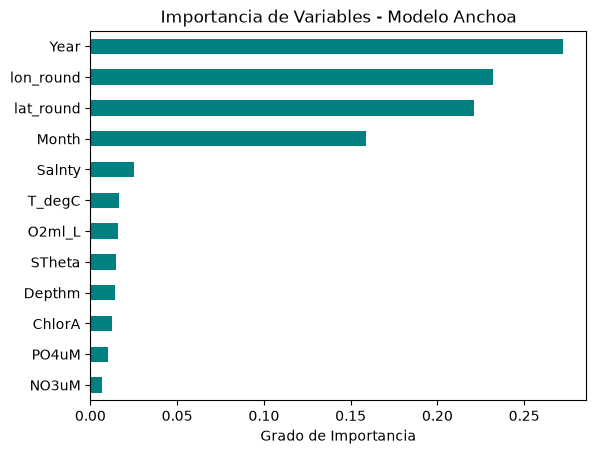

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Obtener importancias de la anchoa (o sardina)
importancias = pd.Series(rf_anchoa.feature_importances_, index=features_validas)
importancias.sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title("Importancia de Variables - Modelo Anchoa")
plt.xlabel("Grado de Importancia")
plt.show()

In [61]:
import joblib

# Guardar modelo de anchoa
joblib.dump(rf_anchoa, 'modelo_anchoa_rf.pkl')
# Guardar modelo de sardina
joblib.dump(rf_sardina, 'modelo_sardina_rf.pkl')
print("¡Modelos guardados exitosamente!")

¡Modelos guardados exitosamente!


# Gráfico de dispersión geográfica
Veamos gráficamente si nuestro modelo aprendió y puede predecir dónde estarán los cardúmenes en un mapa

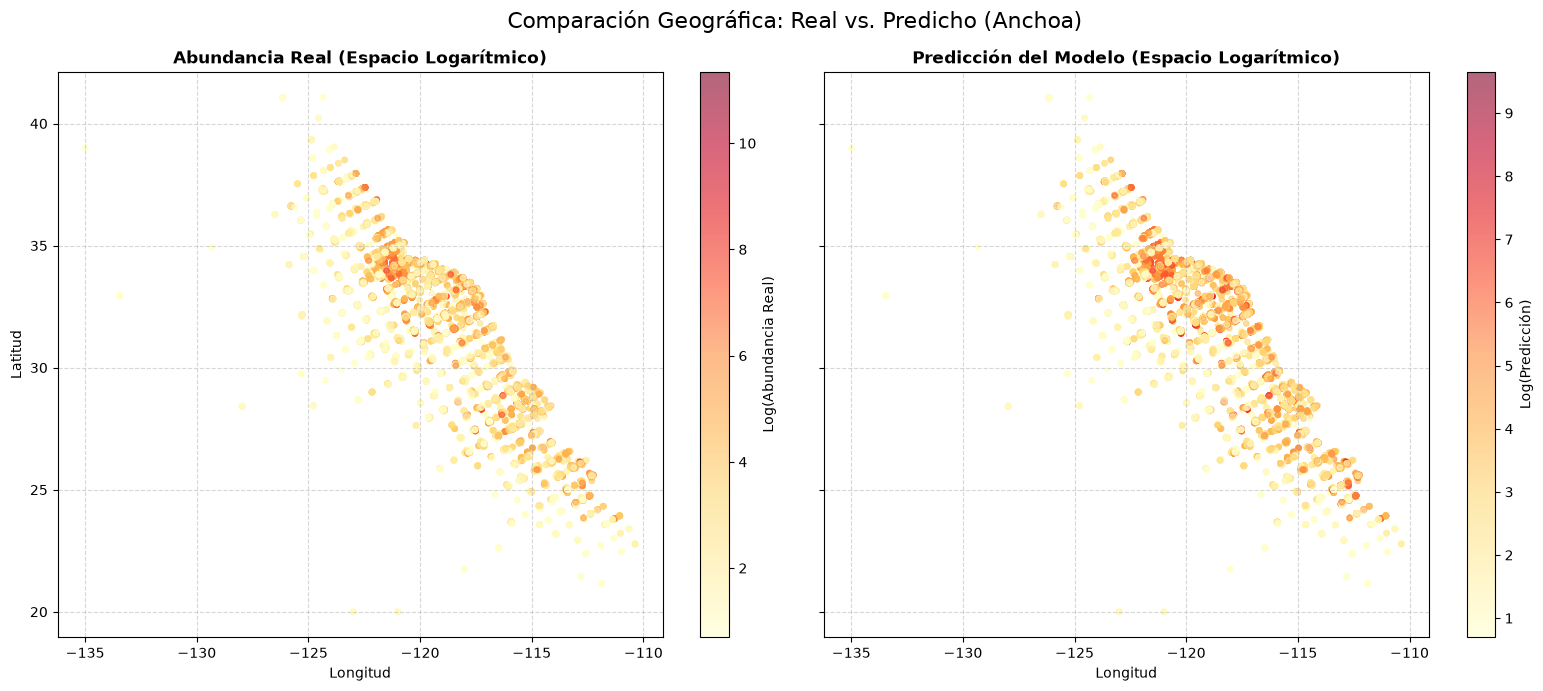

: 

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Crear un DataFrame con los resultados del conjunto de prueba
df_resultados = pd.DataFrame({
    'lat': X_test_a['lat_round'],
    'lon': X_test_a['lon_round'],
    'Real_Log': y_test_a_log,
    'Pred_Log': y_pred_log_a
})

# 2. Configurar la figura con dos mapas lado a lado (Real vs Predicho)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# --- MAPA 1: DATOS REALES ---
sc1 = axes[0].scatter(
    df_resultados['lon'], df_resultados['lat'], 
    c=df_resultados['Real_Log'], cmap='YlOrRd', alpha=0.6, s=15
)
axes[0].set_title('Abundancia Real (Espacio Logarítmico)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
axes[0].grid(True, linestyle='--', alpha=0.5)
plt.colorbar(sc1, ax=axes[0], label='Log(Abundancia Real)')

# --- MAPA 2: PREDICCIONES DEL MODELO ---
sc2 = axes[1].scatter(
    df_resultados['lon'], df_resultados['lat'], 
    c=df_resultados['Pred_Log'], cmap='YlOrRd', alpha=0.6, s=15
)
axes[1].set_title('Predicción del Modelo (Espacio Logarítmico)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Longitud')
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.colorbar(sc2, ax=axes[1], label='Log(Predicción)')

plt.suptitle('Comparación Geográfica: Real vs. Predicho (Anchoa)', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()